# Data Analysis & Preprocessing



This notebook contains the full data preparation process:

 1. Data consistency assessment
 2. Choosing relevant features
 3. Ascertaining whether stacking seasons as features causes dimentionality issues 
 4. Identifying NaN values & treating them accordingly
 5. Considering multi-algorithm decision process for different roles 

## Frameworks & Libraries

In [20]:
# Path Setup
import sys
sys.path.append("../devkit")

# Helper Functions
from utils import mkSeasonDf, nan_groups, ROLE, LEADS
from role_from_nan import derive_groups, derive_groups_global, plot_dendrograms

# Data Processing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

## Data Setup

In [21]:
df21 = mkSeasonDf("2021-2022")
df22 = mkSeasonDf("2022-2023")
df23 = mkSeasonDf("2023-2024")
df24 = mkSeasonDf("2024-2025")
df25 = mkSeasonDf("2025-2026")

dfs = {"21-22": df21, "22-23": df22, "23-24": df23,
       "24-25": df24, "25-26": df25}

In [22]:
# Checks for invalid column sizes
for i in dfs.values(): print(f"FLAGGED [{i}]: under 16 columns! ({len(i.columns)}):") if len(i.columns) < 16 else None

In [23]:
df21.head()

,league,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
0,2. Bundesliga,M. Thiaw,Newcastle United,Schalke 04,RCB,24,25000000,2029-06-30,31,2718,...,NaN,2.98,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
1,2. Bundesliga,N. Füllkrug,Milan,Werder Bremen,CF,33,15000000,2028-06-30,33,2693,...,NaN,0.00,NaN,NaN,0.00,0.00,0.0,0.03,2,100.0
2,2. Bundesliga,J. Beste,Freiburg,Jahn Regensburg,"RW, RAMF",27,15000000,2030-06-30,26,2077,...,NaN,0.22,NaN,NaN,0.52,0.04,100.0,2.64,0,0.0
3,2. Bundesliga,K. Itakura,Ajax,Schalke 04,"CB, RCB",29,12000000,2029-06-30,31,2838,...,NaN,2.66,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
4,2. Bundesliga,E. Dinkçi,Heidenheim,Werder Bremen,"RW, RAMF, CF",24,12000000,2026-06-30,21,701,...,NaN,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0


## NaN Values

### Global Verification

The code below bins and identifies NaN values based on their percentages in each column. Let's check similarity between seasons:

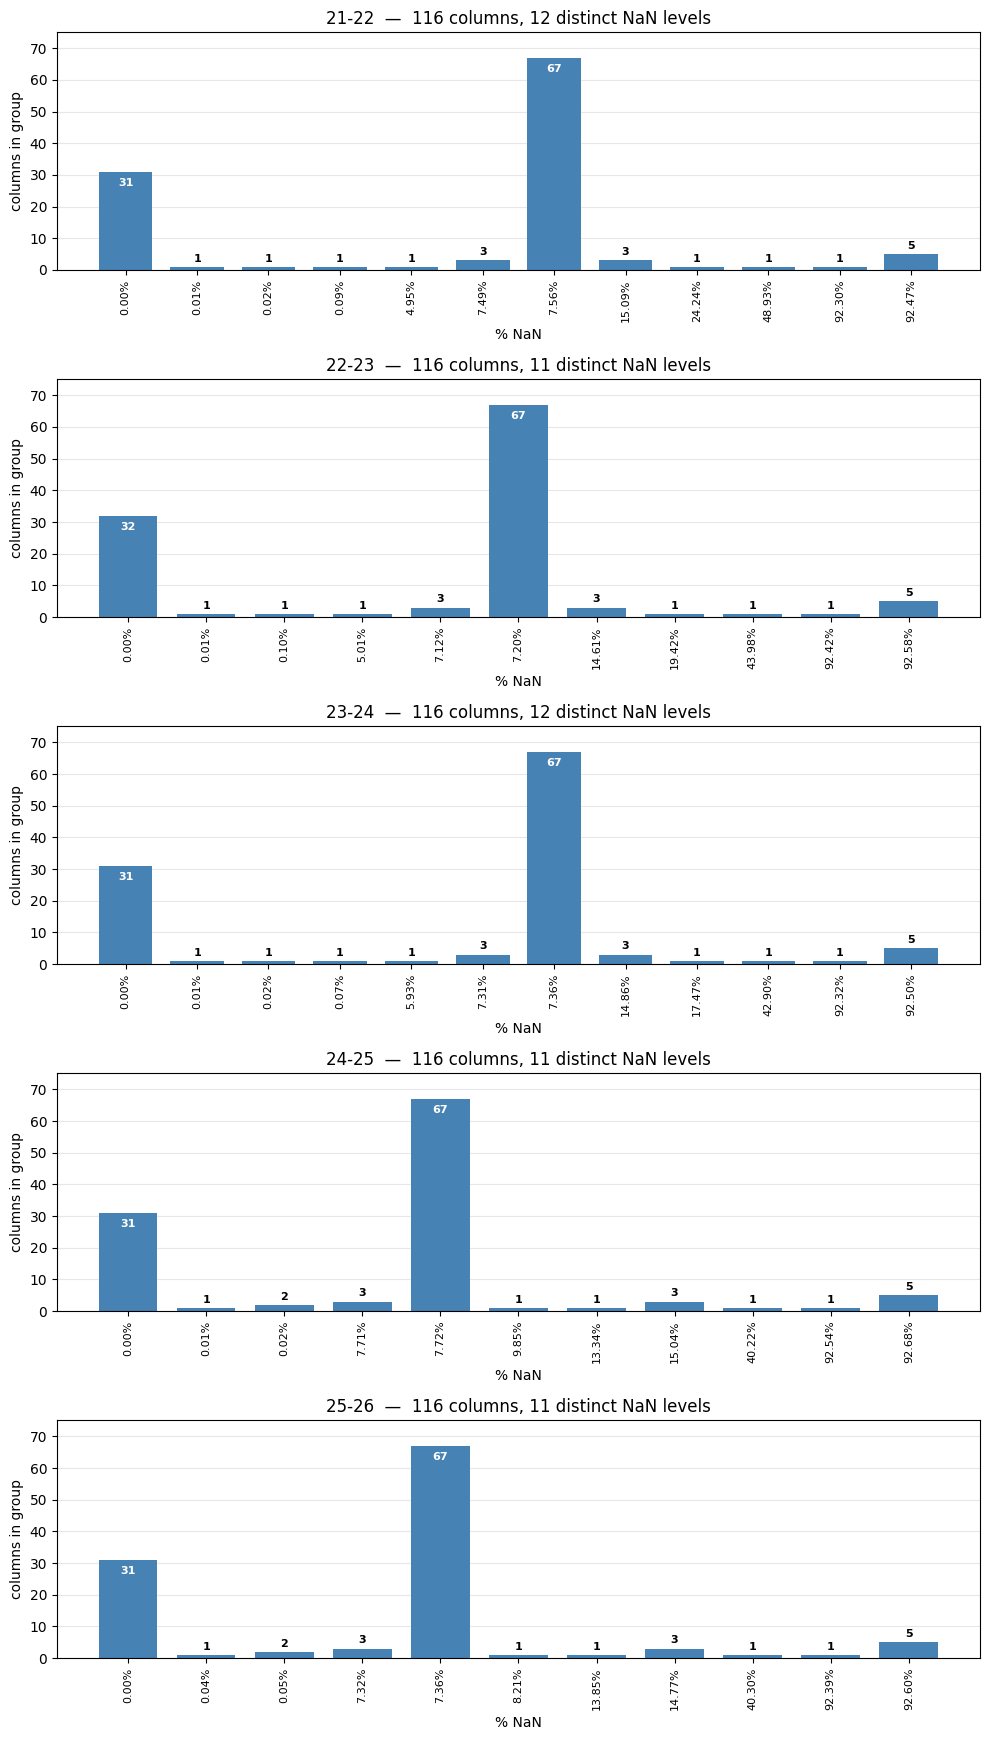

In [24]:
miss = pd.DataFrame({y: d.isna().mean().mul(100) for y, d in dfs.items()})  # rows=columns, cols=years
fig, axes = plt.subplots(len(dfs), 1, figsize=(10, 3.5 * len(dfs)), squeeze=False)
all_groups = {
    year: nan_groups(df, name=year, verbose=0, ax=axes[i, 0])
    for i, (year, df) in enumerate(dfs.items())
}
plt.tight_layout()

This shows us that information stays relatively consistent throughout seasons, when considering all leagues and roles globally.

The goal for this function is to identify whether our role separation is efficient in eliminating irrelevant columns (for strikers, defended goals is irrelevant, thus most likely completely empty for them.)

### Separating Roles

<br>

<div style="display:flex; gap:24px; align-items:flex-start; justify-content:center;">

<table>
<thead><tr><th>Role</th><th>Code</th><th>Full position</th></tr></thead>
<tbody>
<tr><td><b>GK</b></td><td><code>GK</code></td><td>Goalkeeper (Guarda-redes)</td></tr>
<tr><td rowspan="3"><b>CB</b></td><td><code>CB</code></td><td>Centre-back (Defesa-central)</td></tr>
<tr><td><code>RCB</code></td><td>Right centre-back (Defesa-central direito)</td></tr>
<tr><td><code>LCB</code></td><td>Left centre-back (Defesa-central esquerdo)</td></tr>
<tr><td rowspan="4"><b>FB</b></td><td><code>RB</code></td><td>Right-back (Lateral direito)</td></tr>
<tr><td><code>LB</code></td><td>Left-back (Lateral esquerdo)</td></tr>
<tr><td><code>RWB</code></td><td>Right wing-back (Ala direito)</td></tr>
<tr><td><code>LWB</code></td><td>Left wing-back (Ala esquerdo)</td></tr>
<tr><td rowspan="3"><b>DM</b></td><td><code>DMF</code></td><td>Defensive midfielder (Médio defensivo)</td></tr>
<tr><td><code>RDMF</code></td><td>Right defensive midfielder (Médio defensivo direito)</td></tr>
<tr><td><code>LDMF</code></td><td>Left defensive midfielder (Médio defensivo esquerdo)</td></tr>
</tbody>
</table>

<table>
<thead><tr><th>Role</th><th>Code</th><th>Full position</th></tr></thead>
<tbody>
<tr><td rowspan="3"><b>CM</b></td><td><code>CMF</code></td><td>Central midfielder (Médio-centro)</td></tr>
<tr><td><code>RCMF</code></td><td>Right central midfielder (Médio-centro direito)</td></tr>
<tr><td><code>LCMF</code></td><td>Left central midfielder (Médio-centro esquerdo)</td></tr>
<tr><td><b>AM</b></td><td><code>AMF</code></td><td>Attacking midfielder (Médio ofensivo)</td></tr>
<tr><td rowspan="6"><b>W</b></td><td><code>LW</code></td><td>Left winger (Extremo esquerdo)</td></tr>
<tr><td><code>RW</code></td><td>Right winger (Extremo direito)</td></tr>
<tr><td><code>LWF</code></td><td>Left wing forward (Extremo-avançado esquerdo)</td></tr>
<tr><td><code>RWF</code></td><td>Right wing forward (Extremo-avançado direito)</td></tr>
<tr><td><code>LAMF</code></td><td>Left attacking midfielder / wide (Médio ofensivo esquerdo)</td></tr>
<tr><td><code>RAMF</code></td><td>Right attacking midfielder / wide (Médio ofensivo direito)</td></tr>
<tr><td><b>CF</b></td><td><code>CF</code></td><td>Centre-forward (Ponta de lança)</td></tr>
</tbody>
</table>

</div>

<br>
<br>

We've previously defined the table above as role separation to help us remove unnecessary columns for specific positions. For some, it'll make sense to remove an entire column. For others, we must find mitigation measures.

The idea here is essentially:

<center>
<i>
If two positions really belong to the same role, the columns that are
</i>
</center>

<center>
<i>
"structurally empty" for one should be structurally empty for the other too.
</i>
</center>

So, for every role, we take a lead position (which is the one the role is named after) compute column-wise NaN percentage, flagging any "sibling" position whose NaN profile drifts by more than a specific tolerance of percentage points on any column.

First, let's see if there are any anomalous cases of players with positions outside of our deterministic, manually created roles:

In [25]:
position_col = "Position"
out = []

for season, df in dfs.items():
    pos = df[position_col].fillna("").astype(str)

    def spans_multiple_roles(val):
        codes = [c.strip().upper() for c in val.split(",") if c.strip()]
        if not codes:
            return False                       # blank -> nothing to compare
        buckets = [ROLE.get(c) for c in codes]  # .get -> None for unknown codes
        return any(b != buckets[0] for b in buckets[1:])

    mask = pos.apply(spans_multiple_roles)

    rows = df.loc[mask].copy()
    rows.insert(0, "season", season)
    rows.insert(1, "roles", pos[mask].apply(
        lambda v: ", ".join(str(ROLE.get(c.strip().upper()))
                            for c in v.split(",") if c.strip())))
    out.append(rows)

result = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
result.to_csv("../data/extra/bad_roles.csv", index=False)

ratio_bad = result.groupby("season").size() / pd.Series({y: len(d) for y, d in dfs.items()})
print(f"Percentage of misidentified positions per role, for all seasons: {ratio_bad.mul(100).round(2)}%")

Percentage of misidentified positions per role, for all seasons: season
21-22    39.97
22-23    40.70
23-24    39.98
24-25    41.26
25-26    41.51
dtype: float64%


This means our ROLE grouping is too strict, and we must follow the NaN rationale for consistency.


GLOBAL (pooled)   (2 groups, cut @ 9.95pp)
  group 1: AMF(n=6634), CB(n=2483), CF(n=24532), DMF(n=4616), LAMF(n=3978), LB(n=10822), LCB(n=10981), LCMF(n=9640), LDMF(n=2824), LW(n=6733), LWB(n=1977), LWF(n=1546), RAMF(n=3997), RB(n=11309), RCB(n=11415), RCMF(n=9767), RDMF(n=2898), RW(n=6749), RWB(n=2041), RWF(n=1643)
  group 2: GK(n=11247)
  ROLE too strict (data merges different buckets):
    [AM, CB, CF, CM, DM, FB, W] -> AMF, CB, CF, DMF, LAMF, LB, LCB, LCMF, LDMF, LW, LWB, LWF, RAMF, RB, RCB, RCMF, RDMF, RW, RWB, RWF


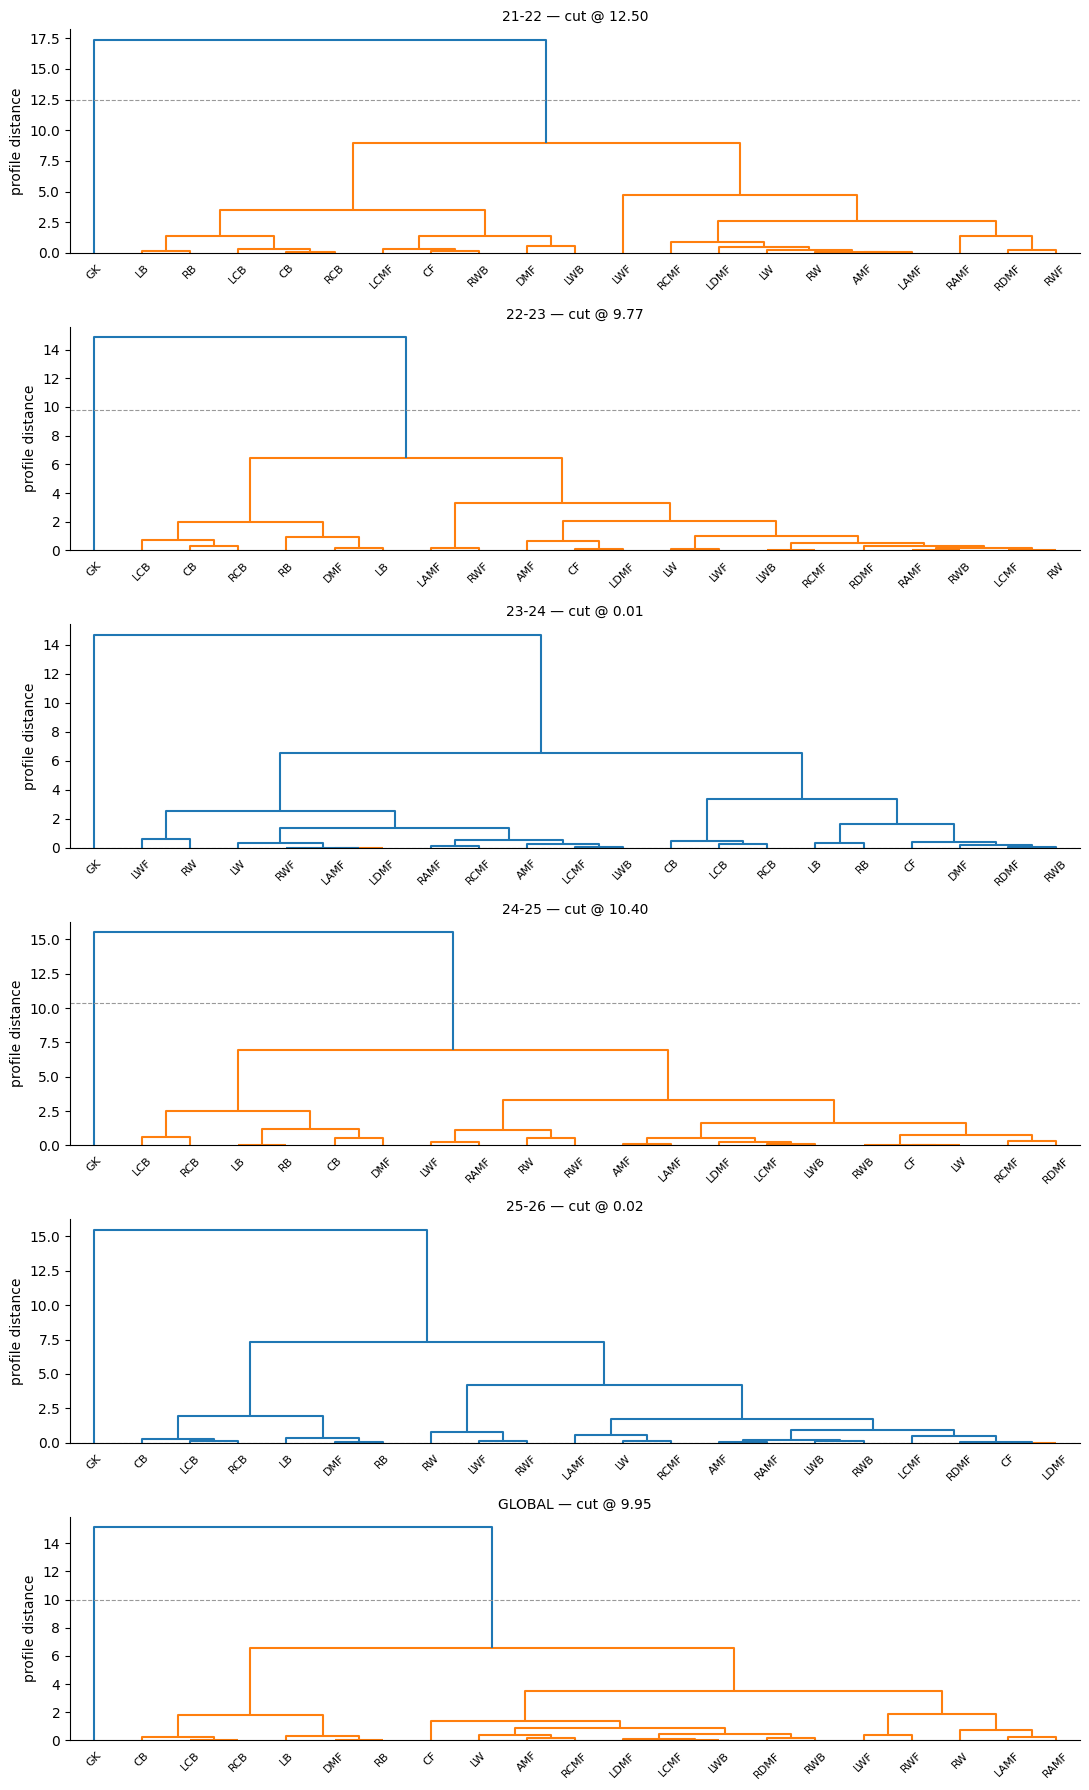

In [26]:
# per season, independent
per_season = {yr: derive_groups(df, name=yr, role=ROLE) for yr, df in dfs.items()}

# global, all seasons pooled (bigger samples -> cleaner profiles)
glob = derive_groups_global(dfs, role=ROLE)          # how="mean" for season-consensus instead

fig, _ = plot_dendrograms(per_season, global_result=glob)

Even this attempt shows how difficult it is to save information. So, for this reason, we'll be considering a simplification of the information: only the 16 default columns from a regular, unfiltered download from Wyscout.

### Simplifying Features

Let's see the difference in NaN inconsistency when using only Wyscout's regular download 16 default features: 

In [27]:
df_smaller = pd.read_excel("../data/extra/16_cols.xlsx")
df_smaller.columns

Index(['Player', 'Team', 'Position', 'Age', 'Market value', 'Contract expires',
       'Matches played', 'Minutes played', 'Goals', 'xG', 'Birth country',
       'Passport country', 'Foot', 'Height', 'Weight', 'On loan'],
      dtype='object')

Default features are far too simple to be relevant in AI prediction, so we must scratch this.


21-22   (26229 rows, 16 columns)
 0.00%  n=10   [Player, Age, Market value, Matches played, Minutes played, Goals, xG, Height,
                Weight, On loan]
 0.01%  n=1    [Passport country]
 0.02%  n=1    [Birth country]
 0.09%  n=1    [Position]
 4.95%  n=1    [Foot]
24.24%  n=1    [Team]
48.93%  n=1    [Contract expires]

22-23   (26557 rows, 16 columns)
 0.00%  n=11   [Player, Age, Market value, Matches played, Minutes played, Goals, xG, Passport
                country, Height, Weight, On loan]
 0.01%  n=1    [Birth country]
 0.10%  n=1    [Position]
 5.01%  n=1    [Foot]
19.42%  n=1    [Team]
43.98%  n=1    [Contract expires]

23-24   (26909 rows, 16 columns)
 0.00%  n=10   [Player, Age, Market value, Matches played, Minutes played, Goals, xG, Height,
                Weight, On loan]
 0.01%  n=1    [Passport country]
 0.02%  n=1    [Birth country]
 0.07%  n=1    [Position]
 5.93%  n=1    [Foot]
17.47%  n=1    [Team]
42.90%  n=1    [Contract expires]

24-25   (28579 rows, 16 c

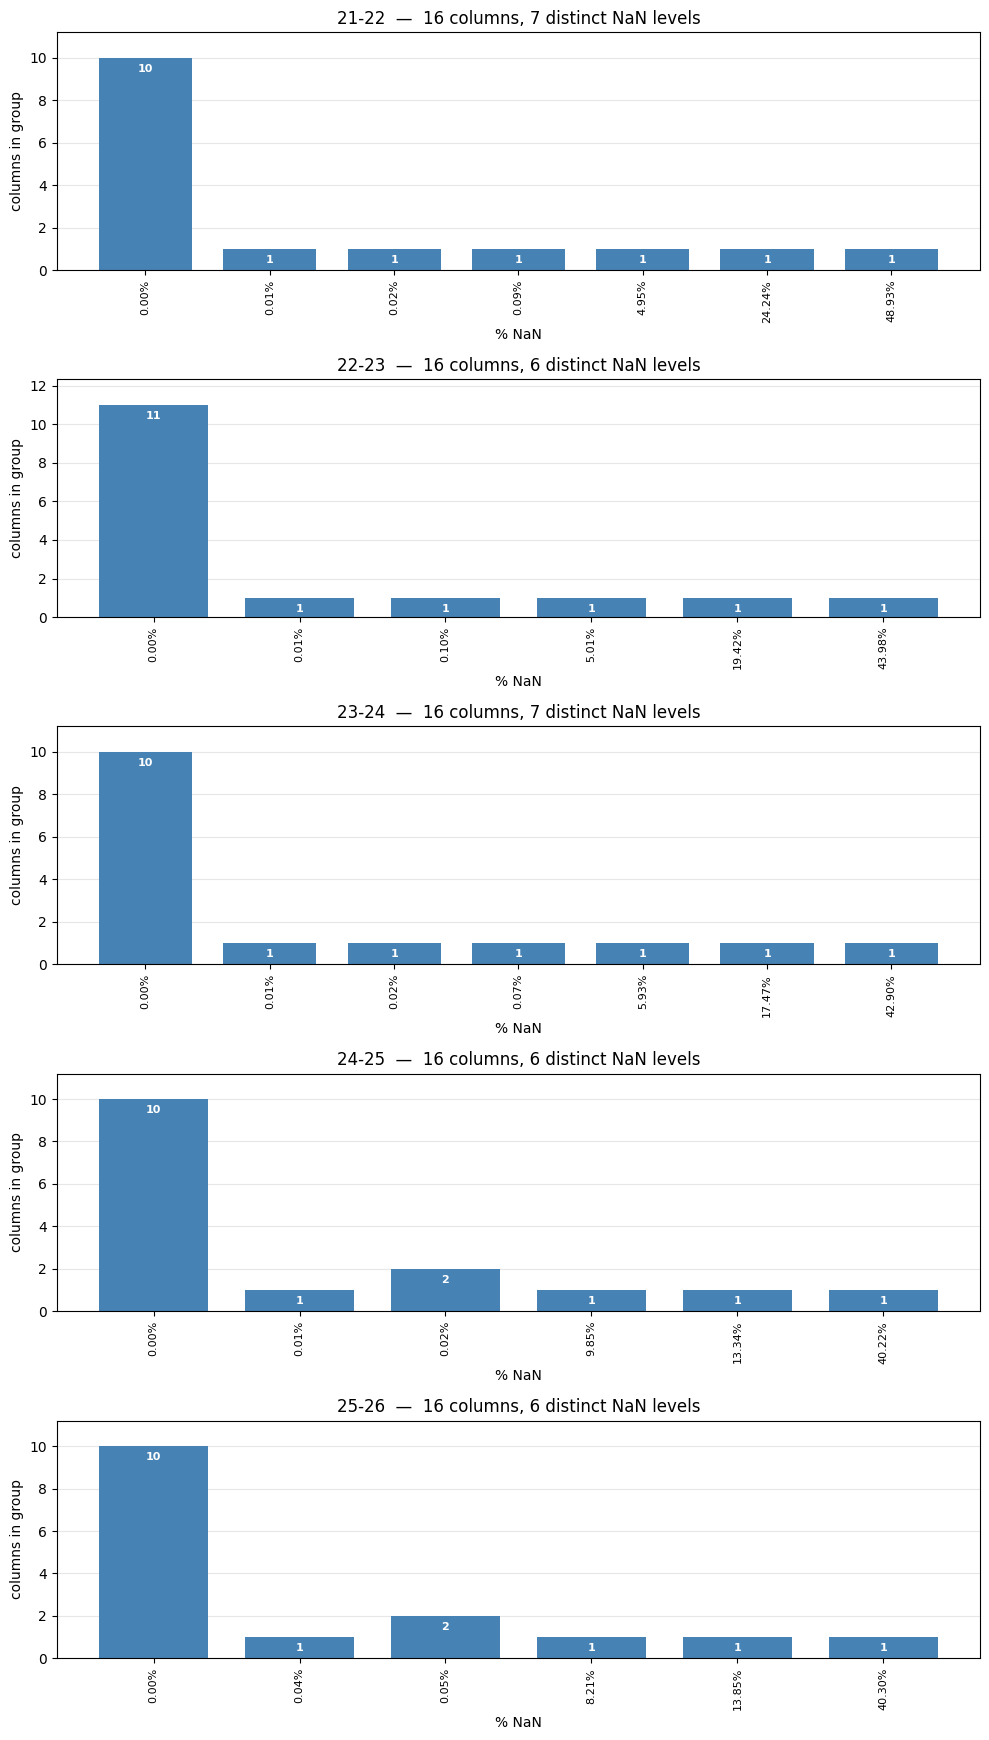

In [29]:
miss = pd.DataFrame({y: d.isna().mean().mul(100) for y, d in dfs_simplified.items()})  # rows=columns, cols=years
fig, axes = plt.subplots(len(dfs_simplified), 1, figsize=(10, 3.5 * len(dfs_simplified)), squeeze=False)
all_groups = {
    year: nan_groups(df, name=year, verbose=2, ax=axes[i, 0])
    for i, (year, df) in enumerate(dfs_simplified.items())
}
plt.tight_layout()